In [7]:
import re
import numpy as np
import xarray as xr
import pandas as pd
from flights_io  import get_matched_flights
from flight_processing import process_flight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

In [8]:
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [9]:
results = []

for flight in flights:
    out = process_flight(flight)

    # First find common times between neph and AMS
    #common_times = np.intersect1d(out.neph_resampled_time, out.ams_resampled_time)
    #print(out.ams.time.values)
    # Then intersect with AMS and core
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    sp2_resampled_matched = out.sp2.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)
    Dg_aligned_matched = out.Dgs.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = out.PM_ratio.sel(PCAS2TSPM = common_times)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    AS = ams_resampled_matched['NH4_2SO4'].values
    AN = ams_resampled_matched['NH4NO3'].values
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', flight.core)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'Exctinction': PSAP_matched+TSC_green,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number
    })

In [10]:
# Combine all flight data
combined_data = []
for entry in results:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'rBC': entry['BC'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'OA': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Ext': entry['Exctinction'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

In [11]:
scattering_vars = ['TSC_green']
absorption_vars = ['ABS_PSAP']
chemistry_vars = ['rBC', 'SO4', 'NH4', 'NO3', 'OA']
other_vars = ['CO']

In [19]:
# Features and target
features = df_clean.drop(columns=[
    #'TSC_green','TSC_blue','TSC_red','Flight','ABS_PSAP','DG','AS','AN'
    'Ext','TSC_green','TSC_blue','TSC_red','Flight','ABS_PSAP','DG','AS','AN'
])
target = (df_clean['Ext'])*1e6
#print(len(target))
# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Fit Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate model
# -----------------------------
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# -----------------------------
# 5. Feature importances
# -----------------------------
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=features.columns)
top_features = feat_importances.sort_values(ascending=False)

In [13]:
def plot_rf_importances_and_export_metrics(
    top_features,
    r2,
    rmse,
    features,       # DataFrame used in the model (columns = feature names)
    df_clean,       # cleaned dataset (used for n_measurements)
    X_train,
    X_test,
    target_name,   # e.g. r"$\sigma_{sct}$"
    csv_path="rf_metrics.csv",
    figsize=(7, 4),
    label_fs=13,
    tick_fs=11,
    title_fs=14
):
    """
    Plot only the top feature importances (bar chart) and export regression
    metrics to CSV in a 'Metric'/'Value' format (paper/table-ready).
    """

    # -----------------------
    # (1) Plot: importances
    # -----------------------
    fig, ax = plt.subplots(figsize=figsize)

    # If top_features is a Series (recommended)
    top_features.plot(kind="bar", ax=ax, edgecolor="black", alpha=0.85)

    #ax.set_title(f"Feature Importances for {target_name}", fontsize=title_fs)
    ax.set_ylabel(f"Feature Importances ({target_name})", fontsize=label_fs)
    ax.set_xlabel("", fontsize=label_fs)

    ax.tick_params(axis="x", labelsize=tick_fs, rotation=45)
    ax.tick_params(axis="y", labelsize=tick_fs)

    plt.tight_layout()
    plt.show()

    # -----------------------
    # (2) CSV: metrics table
    # -----------------------
    metrics_df = pd.DataFrame({
        "Metric": ["R2", "RMSE", "n_features", "n_measurements", "Train size", "Test size"],
        "Value": [
            float(r2),
            float(rmse),
            int(features.shape[1]),
            int(len(df_clean)),
            int(len(X_train)),
            int(len(X_test)),
        ]
    })

    metrics_df.to_csv(csv_path, index=False)

    return metrics_df


In [14]:
def plot_manual_pdp_top1_plus4(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    main_figsize=(10, 6),
    grid_figsize=(12, 8),
    label_fs=15,
    tick_fs=12,
    legend_fs=11,
    title_fs=16,
    suptitle_fs=20,
    line_width_main=3,
    line_width_small=2
):
    """
    Plot manual PDPs in two separate figures:
      1) Top-1 most important feature in a dedicated figure
      2) Next 4 features in a 2x2 grid

    Parameters
    ----------
    rf : fitted RandomForestRegressor
    X_train : pandas.DataFrame
        Training feature matrix.
    feat_importances : pandas.Series
        Feature importances indexed by feature name.
    target_name : str
        Name of the predicted target variable.
    unit_str : str, optional
        Unit string appended to y-axis label.
    n_grid : int, optional
        Number of grid points used for PDP calculation.
    main_figsize : tuple, optional
        Figure size for top feature figure.
    grid_figsize : tuple, optional
        Figure size for 2x2 figure.
    label_fs : int, optional
        Axis label font size.
    tick_fs : int, optional
        Tick font size.
    legend_fs : int, optional
        Legend font size.
    title_fs : int, optional
        Axes title font size.
    suptitle_fs : int, optional
        Figure title font size.
    line_width_main : float, optional
        Line width for main PDP.
    line_width_small : float, optional
        Line width for smaller PDPs.

    Returns
    -------
    fig_main : matplotlib.figure.Figure
    ax_main : matplotlib.axes.Axes
    fig_grid : matplotlib.figure.Figure or None
    axes_grid : np.ndarray or None
    """

    def compute_manual_pdp(rf, X_train, feat, n_grid=60):
        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None, None, None

        grid = np.linspace(feat_values.min(), feat_values.max(), n_grid)

        pdp_mean = []
        pdp_std = []

        for val in grid:
            X_temp = X_train.copy()
            X_temp[feat] = val
            preds = rf.predict(X_temp)
            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return grid, np.asarray(pdp_mean), np.asarray(pdp_std)

    # -----------------------------
    # Select top features
    # -----------------------------
    all_features = feat_importances.sort_values(ascending=False).index.tolist()

    if len(all_features) == 0:
        raise ValueError("feat_importances is empty.")

    top_feature = all_features[0]
    next_features = all_features[1:6]

    y_label = f"Predicted {target_name} {unit_str}".strip()

    # -----------------------------
    # Global style for slides
    # -----------------------------
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": title_fs,
        "axes.labelsize": label_fs,
        "xtick.labelsize": tick_fs,
        "ytick.labelsize": tick_fs,
        "legend.fontsize": legend_fs,
        "figure.titlesize": suptitle_fs,
        "axes.linewidth": 1.2,
    })

    # =========================================================
    # Figure 1: Top feature only
    # =========================================================
    fig_main, ax_main = plt.subplots(
        figsize=main_figsize,
        constrained_layout=True
    )

    result = compute_manual_pdp(rf, X_train, top_feature, n_grid=n_grid)

    if result[0] is None:
        ax_main.set_visible(False)
    else:
        grid, pdp_mean, pdp_std = result

        ax_main.plot(
            grid,
            pdp_mean,
            lw=line_width_main,
            label="Mean PDP"
        )
        ax_main.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        #ax_main.set_title(f"Most Important Feature: {top_feature}", loc="left", fontweight="bold")
        ax_main.set_xlabel(top_feature + r' ($\mu g\ m^{-3}$)', fontsize=label_fs)
        ax_main.set_ylabel(y_label, fontsize=label_fs)
        ax_main.tick_params(axis="x", labelsize=tick_fs)
        ax_main.legend(fontsize=legend_fs, frameon=False, loc="lower right")
        ax_main.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax_main.grid(False, axis="x")
        ax_main.spines["top"].set_visible(False)
        ax_main.spines["right"].set_visible(False)

    #fig_main.suptitle(
    #    f"Partial Dependence of {target_name}: Top Feature",
    #    fontsize=suptitle_fs
    #)

    # =========================================================
    # Figure 2: Next 4 features in 2x2
    # =========================================================
    fig_grid = None
    axes_grid = None

    if len(next_features) > 0:
        fig_grid, axes_grid = plt.subplots(
            nrows=2,
            ncols=2,
            figsize=grid_figsize,
            constrained_layout=True,
            sharey=False
        )

        axes_grid = np.asarray(axes_grid).ravel()

        for ax, feat in zip(axes_grid, next_features):
            result = compute_manual_pdp(rf, X_train, feat, n_grid=n_grid)

            if result[0] is None:
                ax.set_visible(False)
                continue

            grid, pdp_mean, pdp_std = result

            ax.plot(
                grid,
                pdp_mean,
                lw=line_width_small,
                label="Mean PDP"
            )
            ax.fill_between(
                grid,
                pdp_mean - pdp_std,
                pdp_mean + pdp_std,
                alpha=0.25,
                label="±1σ"
            )

            #ax.set_title(feat, loc="left")
            ax.set_xlabel(feat + r' ($\mu g\ m^{-3}$)', fontsize=label_fs)
            ax.set_ylabel(y_label, fontsize=label_fs)
            ax.tick_params(axis="x", labelsize=tick_fs)
            ax.legend(fontsize=legend_fs, frameon=False, loc="lower right")
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
            ax.grid(False, axis="x")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        # Hide unused axes if fewer than 4 features
        for j in range(len(next_features), 4):
            axes_grid[j].set_visible(False)

        #fig_grid.suptitle(
        #    f"Partial Dependence of {target_name}: Features 2–5",
        #    fontsize=suptitle_fs
        #)

    plt.show()

    return #fig_main, ax_main, fig_grid, axes_grid

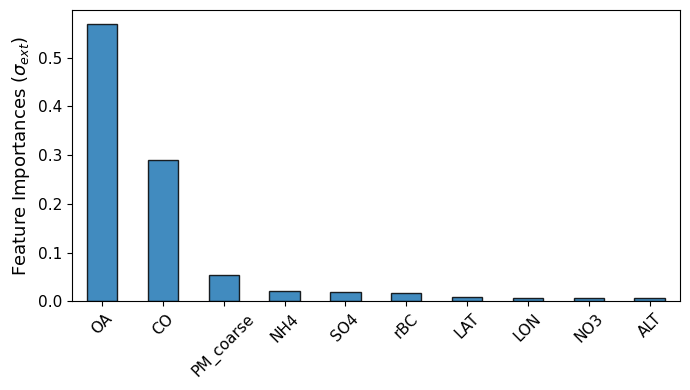

In [20]:
metrics_df = plot_rf_importances_and_export_metrics(
    top_features=top_features,   # e.g., a pandas Series of importances
    r2=r2,
    rmse=rmse,
    features=features,
    df_clean=df_clean,
    X_train=X_train,
    X_test=X_test,
    target_name=r"$\sigma_{ext}$",
    csv_path="rf_ext_metrics.csv"
)

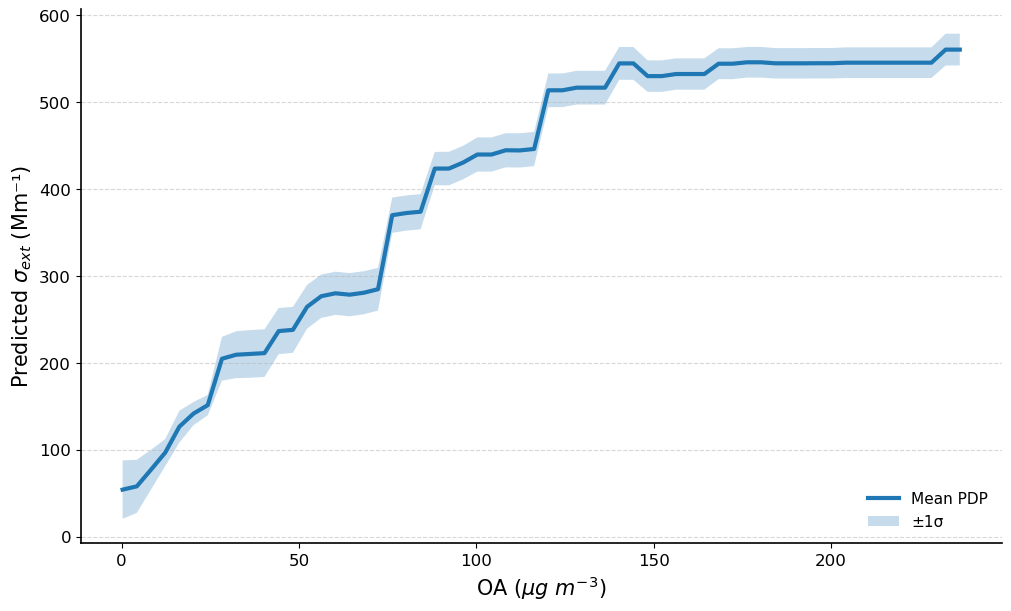

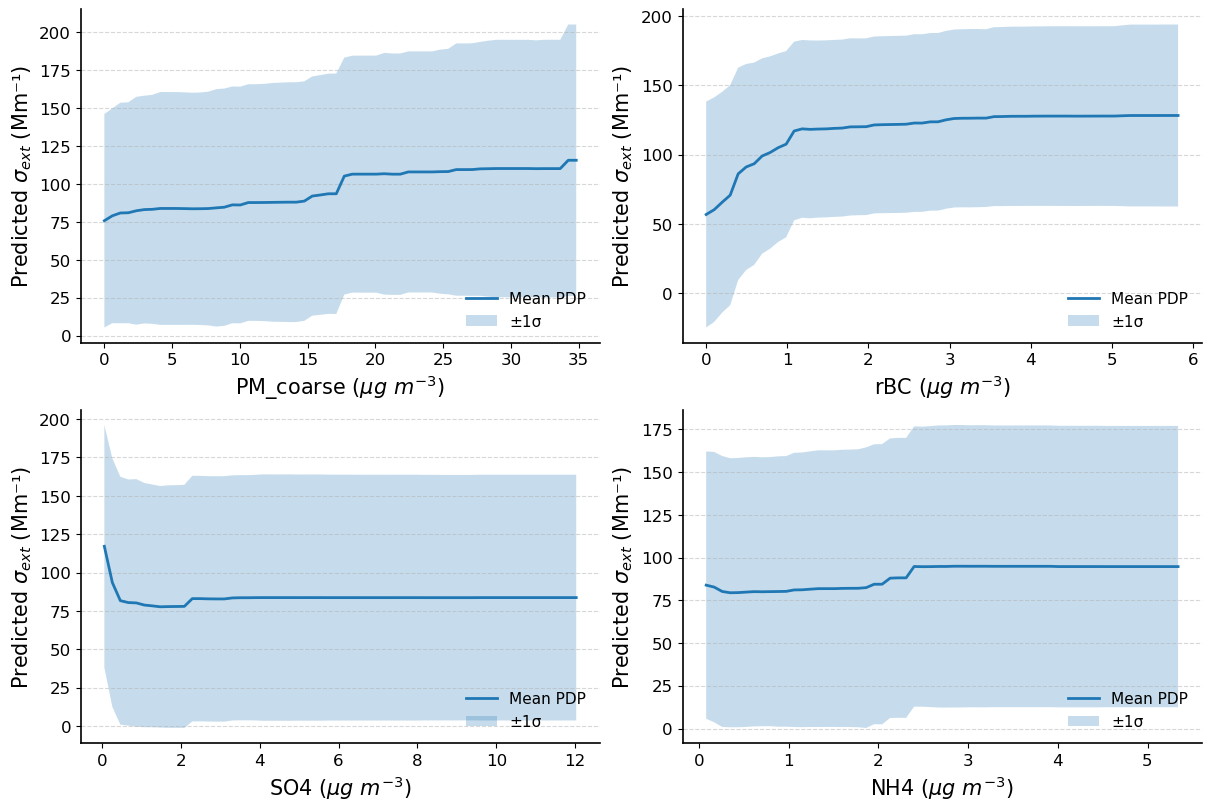

In [37]:
plot_manual_pdp_top1_plus4(
    rf=rf,
    X_train=X_train,
    feat_importances=feat_importances,
    target_name=r"$\sigma_{ext}$"
)

In [ ]:
def plot_manual_pdp_top1_plus4_v2(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    main_figsize=(10, 6),
    grid_figsize=(12, 8),
    label_fs=15,
    tick_fs=12,
    legend_fs=11,
    title_fs=16,
    suptitle_fs=20,
    line_width_main=3,
    line_width_small=2
):
    """
    Plot manual PDPs in two separate figures:
      1) Top-1 most important feature in a dedicated figure
      2) Next 4 features in a 2x2 grid

    Parameters
    ----------
    rf : fitted RandomForestRegressor
    X_train : pandas.DataFrame
        Training feature matrix.
    feat_importances : pandas.Series
        Feature importances indexed by feature name.
    target_name : str
        Name of the predicted target variable.
    unit_str : str, optional
        Unit string appended to y-axis label.
    n_grid : int, optional
        Number of grid points used for PDP calculation.
    main_figsize : tuple, optional
        Figure size for top feature figure.
    grid_figsize : tuple, optional
        Figure size for 2x2 figure.
    label_fs : int, optional
        Axis label font size.
    tick_fs : int, optional
        Tick font size.
    legend_fs : int, optional
        Legend font size.
    title_fs : int, optional
        Axes title font size.
    suptitle_fs : int, optional
        Figure title font size.
    line_width_main : float, optional
        Line width for main PDP.
    line_width_small : float, optional
        Line width for smaller PDPs.

    Returns
    -------
    fig_main : matplotlib.figure.Figure
    ax_main : matplotlib.axes.Axes
    fig_grid : matplotlib.figure.Figure or None
    axes_grid : np.ndarray or None
    """

    def compute_manual_pdp_v2(rf, X_train, feat, n_grid=60):
        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None, None, None, None, None

        grid = np.linspace(feat_values.min(), feat_values.max(), n_grid)

        # Percentiles
        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:
            X_temp = X_train.copy()
            X_temp[feat] = val
            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # -----------------------------
    # Select top features
    # -----------------------------
    all_features = feat_importances.sort_values(ascending=False).index.tolist()

    if len(all_features) == 0:
        raise ValueError("feat_importances is empty.")

    top_feature = all_features[0]
    next_features = all_features[1:5]

    y_label = f"Predicted {target_name} {unit_str}".strip()

    # -----------------------------
    # Global style for slides
    # -----------------------------
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": title_fs,
        "axes.labelsize": label_fs,
        "xtick.labelsize": tick_fs,
        "ytick.labelsize": tick_fs,
        "legend.fontsize": legend_fs,
        "figure.titlesize": suptitle_fs,
        "axes.linewidth": 1.2,
    })

    # =========================================================
    # Figure 1: Top feature only
    # =========================================================
    fig_main, ax_main = plt.subplots(
        figsize=main_figsize,
        constrained_layout=True
    )

    result = compute_manual_pdp_v2(rf, X_train, top_feature, n_grid=n_grid)

    if result[0] is None:
        ax_main.set_visible(False)
    else:
        grid, pdp_mean, pdp_std, p05, p95 = result

        ax_main.plot(
            grid,
            pdp_mean,
            lw=line_width_main,
            label="Mean PDP"
        )

        ax_main.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        # Percentile lines
        ax_main.axvline(
            p05,
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label="5th percentile"
        )

        ax_main.axvline(
            p95,
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label="95th percentile"
        )

        ax_main.set_xlabel(top_feature + r' ($\mu g\ m^{-3}$)', fontsize=label_fs)
        ax_main.set_ylabel(y_label, fontsize=label_fs)
        ax_main.tick_params(axis="x", labelsize=tick_fs)
        ax_main.legend(fontsize=legend_fs, frameon=False, loc="lower right")
        ax_main.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax_main.grid(False, axis="x")
        ax_main.spines["top"].set_visible(False)
        ax_main.spines["right"].set_visible(False)

    #fig_main.suptitle(
    #    f"Partial Dependence of {target_name}: Top Feature",
    #    fontsize=suptitle_fs
    #)

    # =========================================================
    # Figure 2: Next 4 features in 2x2
    # =========================================================
    fig_grid = None
    axes_grid = None

    if len(next_features) > 0:
        fig_grid, axes_grid = plt.subplots(
            nrows=2,
            ncols=2,
            figsize=grid_figsize,
            constrained_layout=True,
            sharey=False
        )

        axes_grid = np.asarray(axes_grid).ravel()

        for ax, feat in zip(axes_grid, next_features):
            result = compute_manual_pdp_v2(rf, X_train, feat, n_grid=n_grid)

            if result[0] is None:
                ax.set_visible(False)
                continue

            grid, pdp_mean, pdp_std, p05, p95 = result

            ax.plot(
                grid,
                pdp_mean,
                lw=line_width_small,
                label="Mean PDP"
            )

            ax.fill_between(
                grid,
                pdp_mean - pdp_std,
                pdp_mean + pdp_std,
                alpha=0.25,
                label="±1σ"
            )

            # Percentile lines
            ax.axvline(
                p05,
                linestyle="--",
                linewidth=1.8,
                alpha=0.8,
                label="5th percentile"
            )

            ax.axvline(
                p95,
                linestyle="--",
                linewidth=1.8,
                alpha=0.8,
                label="95th percentile"
            )

            ax.set_xlabel(feat + r' ($\mu g\ m^{-3}$)', fontsize=label_fs)
            ax.set_ylabel(y_label, fontsize=label_fs)
            ax.tick_params(axis="x", labelsize=tick_fs)
            ax.legend(fontsize=legend_fs, frameon=False, loc="lower right")
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
            ax.grid(False, axis="x")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        # Hide unused axes if fewer than 4 features
        for j in range(len(next_features), 4):
            axes_grid[j].set_visible(False)

        #fig_grid.suptitle(
        #    f"Partial Dependence of {target_name}: Features 2–5",
        #    fontsize=suptitle_fs
        #)

    plt.show()

    return #fig_main, ax_main, fig_grid, axes_grid

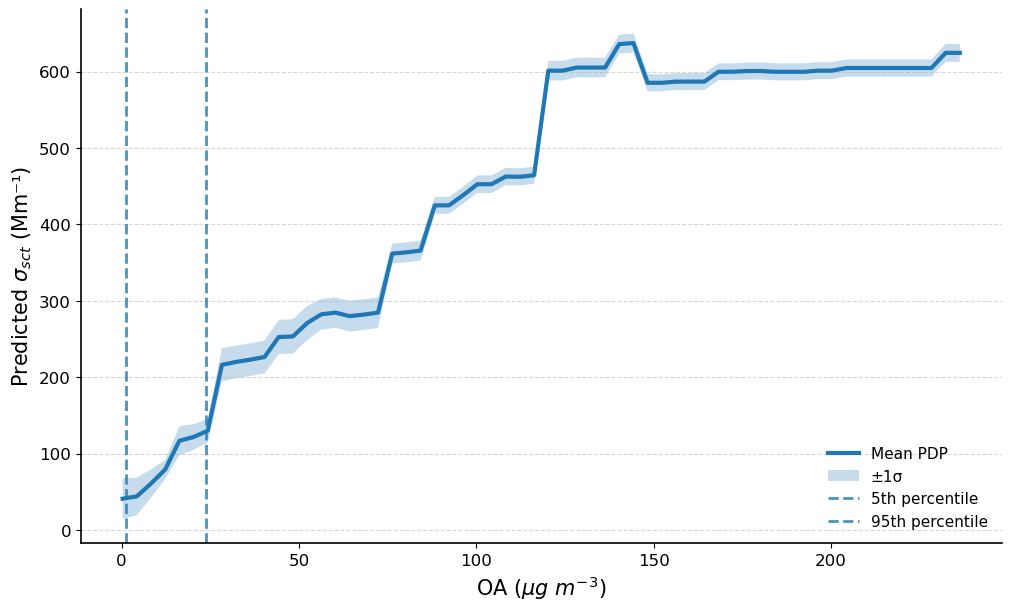

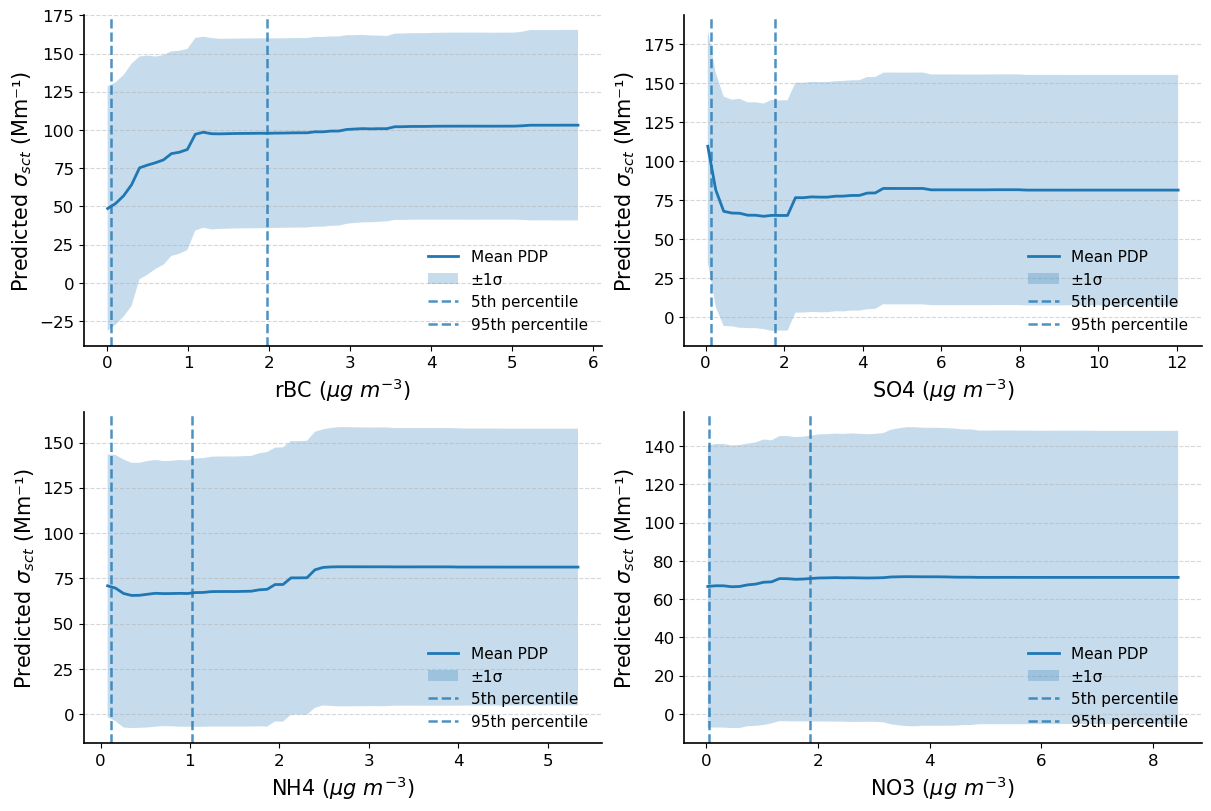

In [ ]:
plot_manual_pdp_top1_plus4_v2(
    rf=rf,
    X_train=X_train,
    feat_importances=feat_importances,
    target_name=r"$\sigma_{sct}$"
)

In [18]:
def plot_manual_pdp_top1_with_percentile_zoom(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    figsize=(10, 6),
    label_fs=15,
    tick_fs=12,
    legend_fs=11,
    title_fs=16,
    line_width=3
):
    """
    Plot TWO PDP figures for the top-1 feature:

    Figure 1
    --------
    Full PDP + 5th/95th percentile vertical lines

    Figure 2
    --------
    PDP restricted to the 5th–95th percentile interval,
    including:
        - linear fit
        - angular coefficient (slope)
        - fitted straight line over PDP

    Returns
    -------
    fig1, ax1, fig2, ax2
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ======================================================
    # Manual PDP
    # ======================================================
    def compute_manual_pdp(rf, X_train, feat, n_grid=60):

        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None

        grid = np.linspace(
            feat_values.min(),
            feat_values.max(),
            n_grid
        )

        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:
            X_temp = X_train.copy()
            X_temp[feat] = val

            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # ======================================================
    # Select top feature
    # ======================================================
    all_features = feat_importances.sort_values(
        ascending=False
    ).index.tolist()

    if len(all_features) == 0:
        raise ValueError("feat_importances is empty.")

    top_feature = all_features[0]

    y_label = f"Predicted {target_name} {unit_str}".strip()

    # ======================================================
    # Compute PDP
    # ======================================================
    result = compute_manual_pdp(
        rf,
        X_train,
        top_feature,
        n_grid=n_grid
    )

    if result is None:
        raise ValueError("Could not compute PDP.")

    grid, pdp_mean, pdp_std, p05, p95 = result

    # ======================================================
    # FIGURE 1 — FULL PDP
    # ======================================================
    fig1, ax1 = plt.subplots(
        figsize=figsize,
        constrained_layout=True
    )

    ax1.plot(
        grid,
        pdp_mean,
        lw=line_width,
        label="Mean PDP"
    )

    ax1.fill_between(
        grid,
        pdp_mean - pdp_std,
        pdp_mean + pdp_std,
        alpha=0.25,
        label="±1σ"
    )

    # Percentile lines
    ax1.axvline(
        p05,
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label="5th percentile"
    )

    ax1.axvline(
        p95,
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label="95th percentile"
    )

    ax1.set_xlabel(
        top_feature + r' ($\mu g\ m^{-3}$)',
        fontsize=label_fs
    )

    ax1.set_ylabel(
        y_label,
        fontsize=label_fs
    )

    ax1.tick_params(axis="both", labelsize=tick_fs)

    ax1.legend(
        fontsize=legend_fs,
        frameon=False,
        loc="lower right"
    )

    ax1.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    ax1.grid(False, axis="x")

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ======================================================
    # FIGURE 2 — ZOOM BETWEEN 5th–95th
    # ======================================================

    # Restrict interval
    mask = (grid >= p05) & (grid <= p95)

    grid_zoom = grid[mask]
    pdp_zoom = pdp_mean[mask]
    std_zoom = pdp_std[mask]

    # ======================================================
    # Linear regression
    # y = a*x + b
    # ======================================================
    slope, intercept = np.polyfit(
        grid_zoom,
        pdp_zoom,
        1
    )

    fit_line = slope * grid_zoom + intercept

    # ======================================================
    # Figure 2
    # ======================================================
    fig2, ax2 = plt.subplots(
        figsize=figsize,
        constrained_layout=True
    )

    # PDP
    ax2.plot(
        grid_zoom,
        pdp_zoom,
        lw=line_width,
        label="Mean PDP"
    )

    ax2.fill_between(
        grid_zoom,
        pdp_zoom - std_zoom,
        pdp_zoom + std_zoom,
        alpha=0.25,
        label="±1σ"
    )

    # Linear fit
    ax2.plot(
        grid_zoom,
        fit_line,
        linestyle="--",
        linewidth=2.5,
        label=f"Linear fit (slope = {slope:.3f})"
    )

    # ======================================================
    # Styling
    # ======================================================
    ax2.set_xlim(p05, p95)

    ax2.set_xlabel(
        top_feature + r' ($\mu g\ m^{-3}$)',
        fontsize=label_fs
    )

    ax2.set_ylabel(
        y_label,
        fontsize=label_fs
    )

    ax2.tick_params(axis="both", labelsize=tick_fs)

    ax2.legend(
        fontsize=legend_fs,
        frameon=False,
        loc="lower right"
    )

    ax2.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    ax2.grid(False, axis="x")

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    plt.show()

    return fig1, ax1, fig2, ax2, slope

In [30]:

filtered_feat_importances_other = feat_importances[['NO3']]

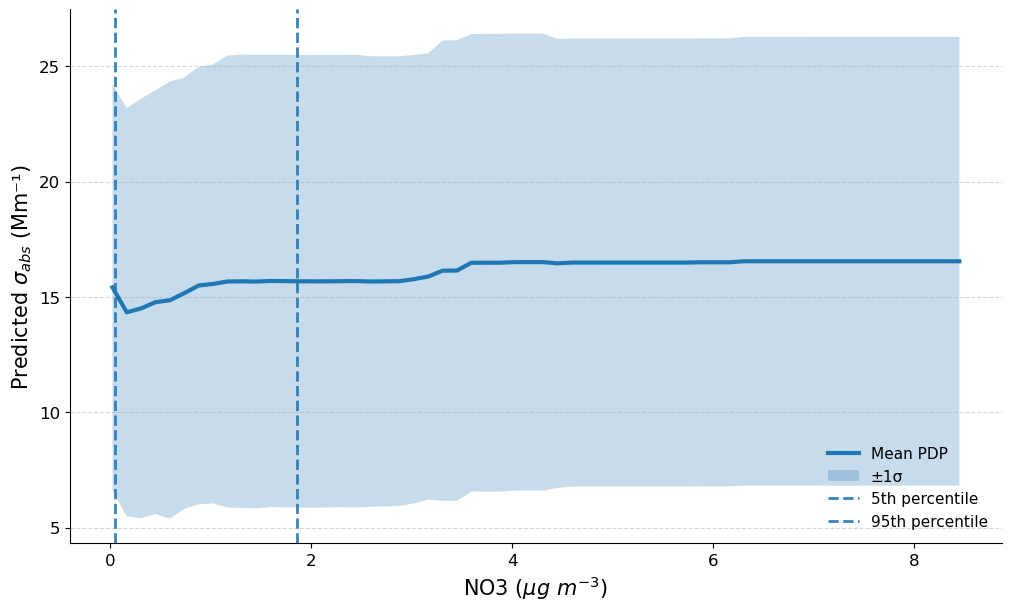

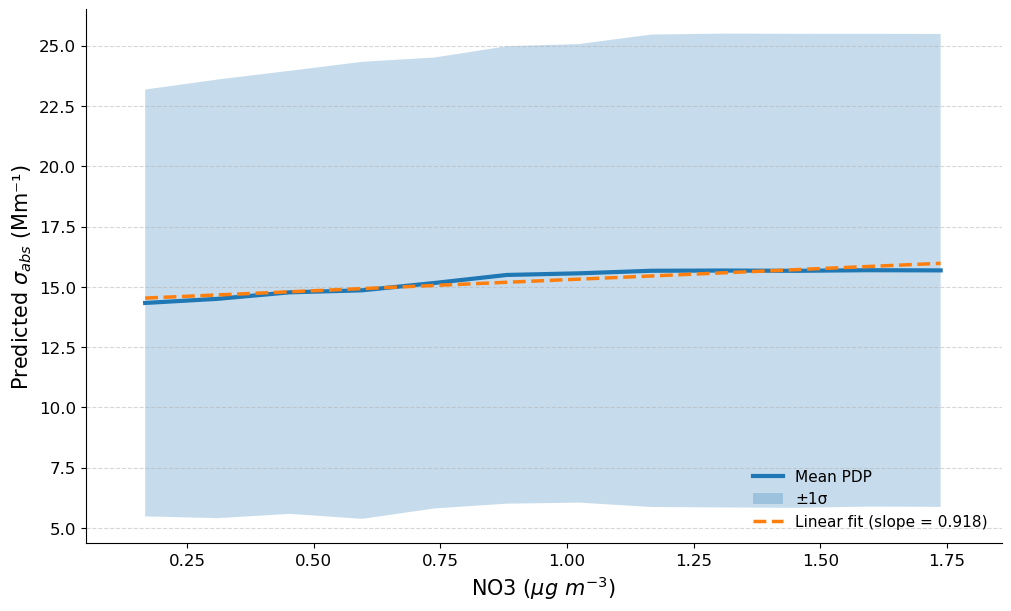

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='NO3 ($\\mu g\\ m^{-3}$)', ylabel='Predicted $\\sigma_{abs}$ (Mm⁻¹)'>,
 <Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='NO3 ($\\mu g\\ m^{-3}$)', ylabel='Predicted $\\sigma_{abs}$ (Mm⁻¹)'>,
 np.float64(0.9179029349838368))

In [31]:
plot_manual_pdp_top1_with_percentile_zoom(
    rf=rf,
    X_train=X_train,
    feat_importances=filtered_feat_importances_other,
    target_name=r"$\sigma_{abs}$"
)

In [27]:
def plot_manual_pdp_top2_with_percentile_zoom(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    figsize=(10, 6),
    label_fs=15,
    tick_fs=12,
    legend_fs=11,
    title_fs=16,
    line_width=3
):
    """
    Plot PDPs for the TWO most important features.

    For EACH feature:
    -----------------
    Figure 1:
        - Full PDP
        - 5th and 95th percentile lines

    Figure 2:
        - Zoomed PDP between percentiles
        - Linear regression fit
        - Slope shown in legend

    Returns
    -------
    results_dict : dict

        Structure:
        {
            feature_name: {
                "fig_full": ...,
                "ax_full": ...,
                "fig_zoom": ...,
                "ax_zoom": ...,
                "slope": ...
            }
        }
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ======================================================
    # Manual PDP
    # ======================================================
    def compute_manual_pdp(
        rf,
        X_train,
        feat,
        n_grid=60
    ):

        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None

        grid = np.linspace(
            feat_values.min(),
            feat_values.max(),
            n_grid
        )

        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:

            X_temp = X_train.copy()

            X_temp[feat] = val

            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # ======================================================
    # Feature selection
    # ======================================================
    all_features = (
        feat_importances
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    if len(all_features) < 2:
        raise ValueError(
            "Need at least 2 features in feat_importances."
        )

    top2_features = all_features[:2]

    y_label = f"Predicted {target_name} {unit_str}".strip()

    # ======================================================
    # Store outputs
    # ======================================================
    results_dict = {}

    # ======================================================
    # Loop through top 2 features
    # ======================================================
    for feat in top2_features:

        # ==================================================
        # Compute PDP
        # ==================================================
        result = compute_manual_pdp(
            rf,
            X_train,
            feat,
            n_grid=n_grid
        )

        if result is None:
            continue

        grid, pdp_mean, pdp_std, p05, p95 = result

        # ==================================================
        # FIGURE 1 — FULL PDP
        # ==================================================
        fig_full, ax_full = plt.subplots(
            figsize=figsize,
            constrained_layout=True
        )

        ax_full.plot(
            grid,
            pdp_mean,
            lw=line_width,
            label="Mean PDP"
        )

        ax_full.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        # Percentile lines
        ax_full.axvline(
            p05,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="5th percentile"
        )

        ax_full.axvline(
            p95,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="95th percentile"
        )

        ax_full.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_full.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_full.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_full.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_full.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_full.grid(False, axis="x")

        ax_full.spines["top"].set_visible(False)
        ax_full.spines["right"].set_visible(False)

        #ax_full.set_title(
        #    f"{feat} — Full PDP",
        #    fontsize=title_fs
        #)

        # ==================================================
        # ZOOM BETWEEN PERCENTILES
        # ==================================================
        mask = (
            (grid >= p05)
            &
            (grid <= p95)
        )

        grid_zoom = grid[mask]
        pdp_zoom = pdp_mean[mask]
        std_zoom = pdp_std[mask]

        # ==================================================
        # Linear fit
        # ==================================================
        slope, intercept = np.polyfit(
            grid_zoom,
            pdp_zoom,
            1
        )

        fit_line = (
            slope * grid_zoom
            + intercept
        )

        # ==================================================
        # FIGURE 2 — ZOOM
        # ==================================================
        fig_zoom, ax_zoom = plt.subplots(
            figsize=figsize,
            constrained_layout=True
        )

        ax_zoom.plot(
            grid_zoom,
            pdp_zoom,
            lw=line_width,
            label="Mean PDP"
        )

        ax_zoom.fill_between(
            grid_zoom,
            pdp_zoom - std_zoom,
            pdp_zoom + std_zoom,
            alpha=0.25,
            label="±1σ"
        )

        # Linear fit
        ax_zoom.plot(
            grid_zoom,
            fit_line,
            linestyle="--",
            linewidth=2.5,
            label=f"Linear fit (slope = {slope:.3f})"
        )

        # ==================================================
        # Styling
        # ==================================================
        ax_zoom.set_xlim(p05, p95)

        ax_zoom.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_zoom.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_zoom.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_zoom.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_zoom.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_zoom.grid(False, axis="x")

        ax_zoom.spines["top"].set_visible(False)
        ax_zoom.spines["right"].set_visible(False)

        #ax_zoom.set_title(
        #    f"{feat} — Zoomed PDP",
        #    fontsize=title_fs
        #)

        # ==================================================
        # Save outputs
        # ==================================================
        results_dict[feat] = {
            "fig_full": fig_full,
            "ax_full": ax_full,
            "fig_zoom": fig_zoom,
            "ax_zoom": ax_zoom,
            "slope": slope
        }

    plt.show()

    return results_dict

In [16]:
filtered_feat_importances = feat_importances[['rBC', 'OA']]

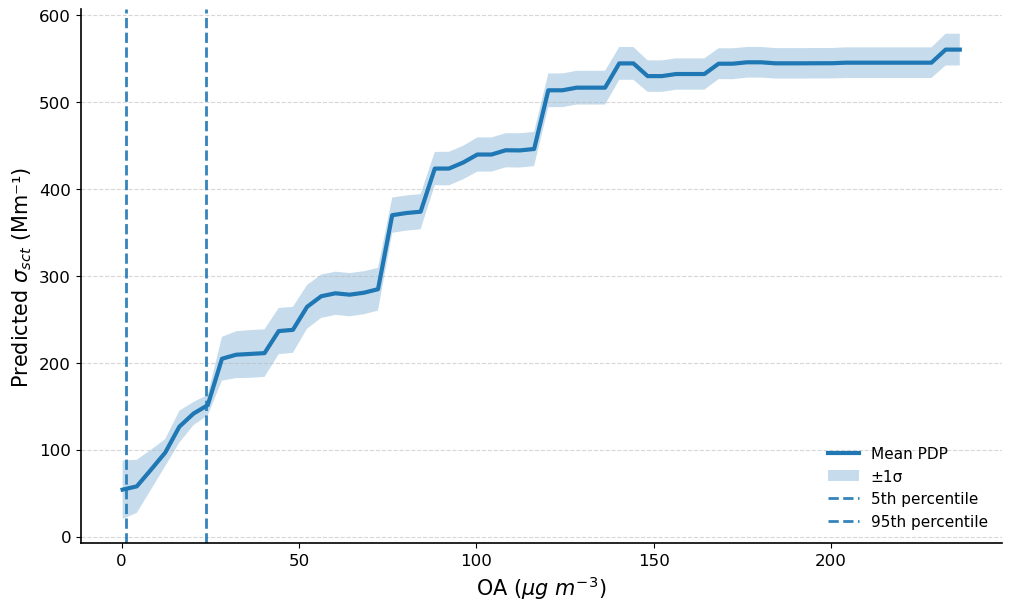

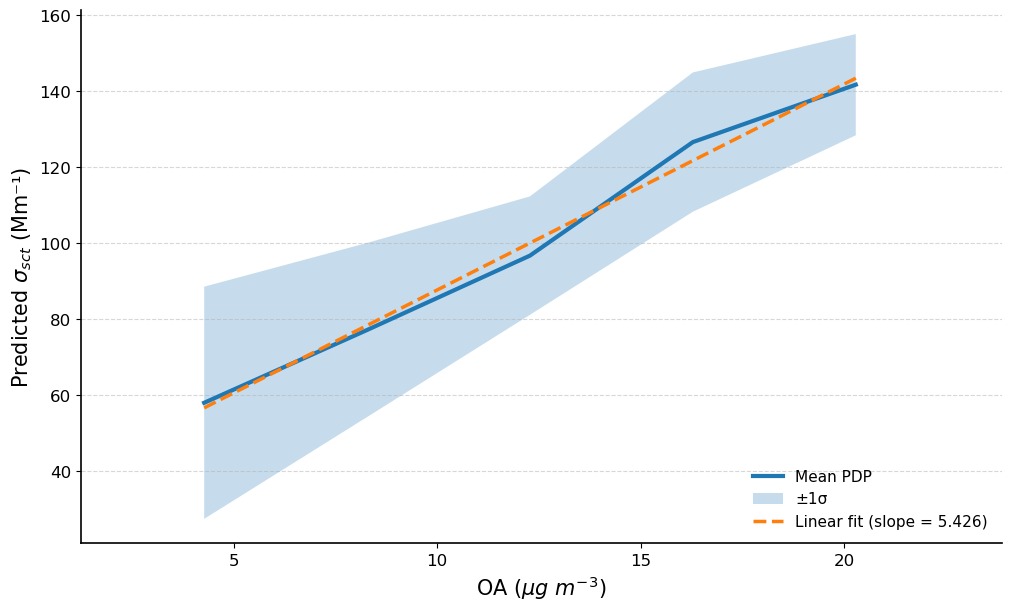

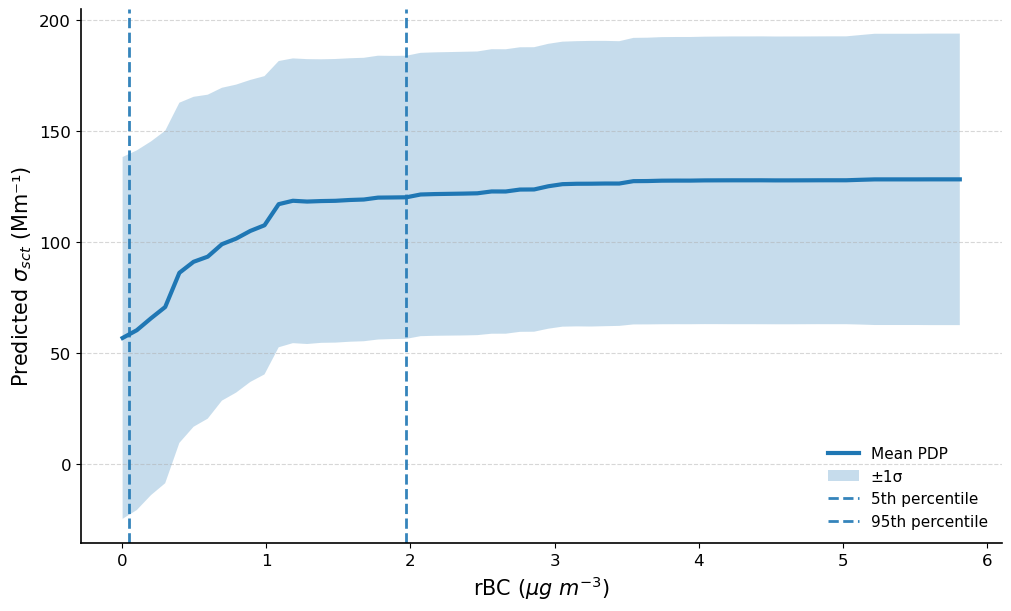

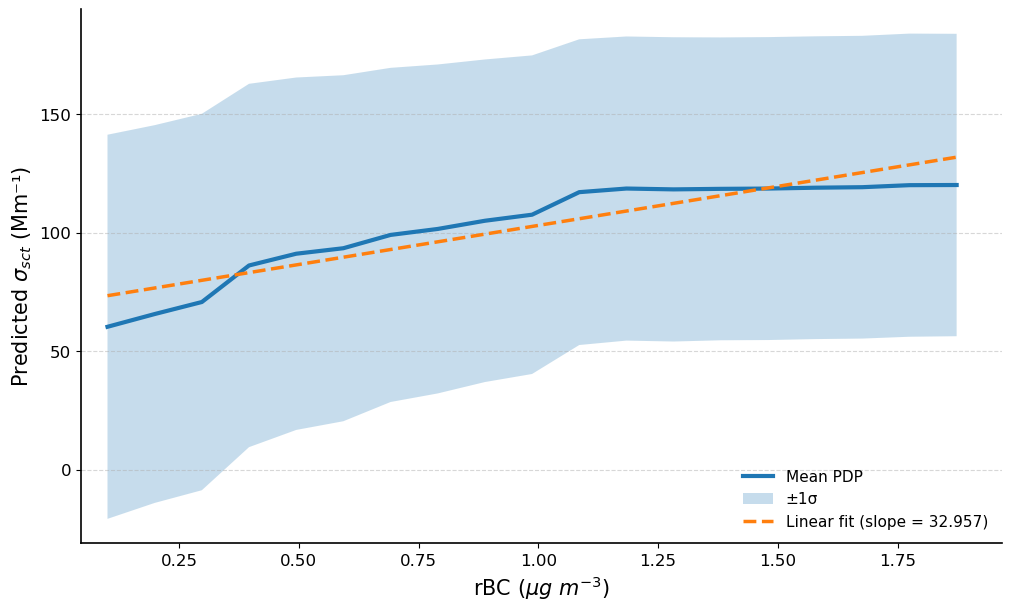

OA 5.426297202390497
rBC 32.95675450752248


In [39]:
results = plot_manual_pdp_top2_with_percentile_zoom(
    rf=rf,
    X_train=X_train,
    feat_importances=filtered_feat_importances,
    target_name=r"$\sigma_{sct}$"
)

for feat in results:
    print(
        feat,
        results[feat]["slope"]
    )

In [40]:
def plot_manual_pdp_top2_with_percentile_zoom_uncertainty(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    figsize=(10, 6),
    label_fs=15,
    tick_fs=12,
    legend_fs=11,
    title_fs=16,
    line_width=3
):
    """
    Plot PDPs for the TWO most important features.

    For EACH feature:
    -----------------
    Figure 1:
        - Full PDP
        - 5th and 95th percentile lines

    Figure 2:
        - Zoomed PDP between percentiles
        - Weighted linear regression
        - Slope uncertainty propagated from PDP std

    Returns
    -------
    results_dict : dict
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ======================================================
    # Manual PDP
    # ======================================================
    def compute_manual_pdp(
        rf,
        X_train,
        feat,
        n_grid=60
    ):

        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None

        grid = np.linspace(
            feat_values.min(),
            feat_values.max(),
            n_grid
        )

        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:

            X_temp = X_train.copy()

            X_temp[feat] = val

            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # ======================================================
    # Select top 2 features
    # ======================================================
    all_features = (
        feat_importances
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    if len(all_features) < 2:
        raise ValueError(
            "Need at least 2 features."
        )

    top2_features = all_features[:2]

    y_label = (
        f"Predicted {target_name} {unit_str}"
    ).strip()

    # ======================================================
    # Store outputs
    # ======================================================
    results_dict = {}

    # ======================================================
    # Loop over top-2 features
    # ======================================================
    for feat in top2_features:

        # ==================================================
        # Compute PDP
        # ==================================================
        result = compute_manual_pdp(
            rf,
            X_train,
            feat,
            n_grid=n_grid
        )

        if result is None:
            continue

        grid, pdp_mean, pdp_std, p05, p95 = result

        # ==================================================
        # FIGURE 1 — FULL PDP
        # ==================================================
        fig_full, ax_full = plt.subplots(
            figsize=figsize,
            constrained_layout=True
        )

        ax_full.plot(
            grid,
            pdp_mean,
            lw=line_width,
            label="Mean PDP"
        )

        ax_full.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        # Percentile lines
        ax_full.axvline(
            p05,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="5th percentile"
        )

        ax_full.axvline(
            p95,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="95th percentile"
        )

        ax_full.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_full.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_full.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_full.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_full.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_full.grid(False, axis="x")

        ax_full.spines["top"].set_visible(False)
        ax_full.spines["right"].set_visible(False)

        ax_full.set_title(
            f"{feat} — Full PDP",
            fontsize=title_fs
        )

        # ==================================================
        # Restrict between 5th–95th percentile
        # ==================================================
        mask = (
            (grid >= p05)
            &
            (grid <= p95)
        )

        grid_zoom = grid[mask]
        pdp_zoom = pdp_mean[mask]
        std_zoom = pdp_std[mask]

        # ==================================================
        # Weighted linear regression
        # ==================================================

        # Prevent division by zero
        safe_std = np.where(
            std_zoom == 0,
            1e-12,
            std_zoom
        )

        # Weights
        weights = 1 / (safe_std ** 2)

        # Weighted fit + covariance matrix
        fit_coeffs, covariance = np.polyfit(
            grid_zoom,
            pdp_zoom,
            deg=1,
            w=weights,
            cov=True
        )

        # Fit parameters
        slope = fit_coeffs[0]
        intercept = fit_coeffs[1]

        # Uncertainties
        slope_unc = np.sqrt(
            covariance[0, 0]
        )

        intercept_unc = np.sqrt(
            covariance[1, 1]
        )

        # Fit line
        fit_line = (
            slope * grid_zoom
            + intercept
        )

        # ==================================================
        # FIGURE 2 — ZOOMED PDP
        # ==================================================
        fig_zoom, ax_zoom = plt.subplots(
            figsize=figsize,
            constrained_layout=True
        )

        # PDP
        ax_zoom.plot(
            grid_zoom,
            pdp_zoom,
            lw=line_width,
            label="Mean PDP"
        )

        ax_zoom.fill_between(
            grid_zoom,
            pdp_zoom - std_zoom,
            pdp_zoom + std_zoom,
            alpha=0.25,
            label="±1σ"
        )

        # Weighted fit
        ax_zoom.plot(
            grid_zoom,
            fit_line,
            linestyle="--",
            linewidth=2.5,
            label=(
                f"Slope = "
                f"{slope:.3f} ± {slope_unc:.3f}"
            )
        )

        # ==================================================
        # Styling
        # ==================================================
        ax_zoom.set_xlim(p05, p95)

        ax_zoom.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_zoom.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_zoom.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_zoom.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_zoom.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_zoom.grid(False, axis="x")

        ax_zoom.spines["top"].set_visible(False)
        ax_zoom.spines["right"].set_visible(False)

        ax_zoom.set_title(
            f"{feat} — Zoomed PDP",
            fontsize=title_fs
        )

        # ==================================================
        # Save outputs
        # ==================================================
        results_dict[feat] = {

            "fig_full": fig_full,
            "ax_full": ax_full,

            "fig_zoom": fig_zoom,
            "ax_zoom": ax_zoom,

            "slope": slope,
            "slope_uncertainty": slope_unc,

            "intercept": intercept,
            "intercept_uncertainty": intercept_unc
        }

    plt.show()

    return results_dict

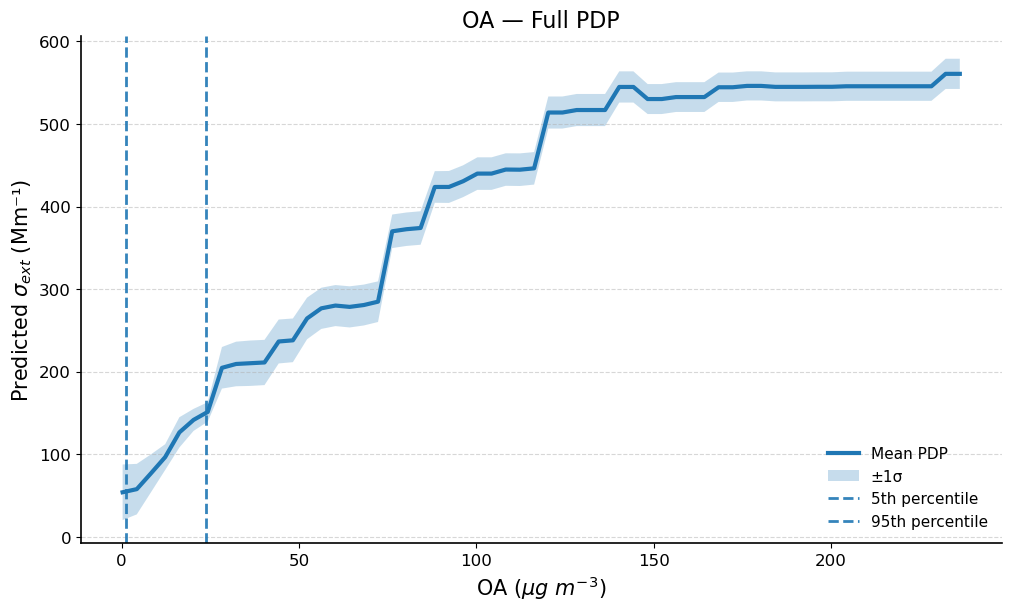

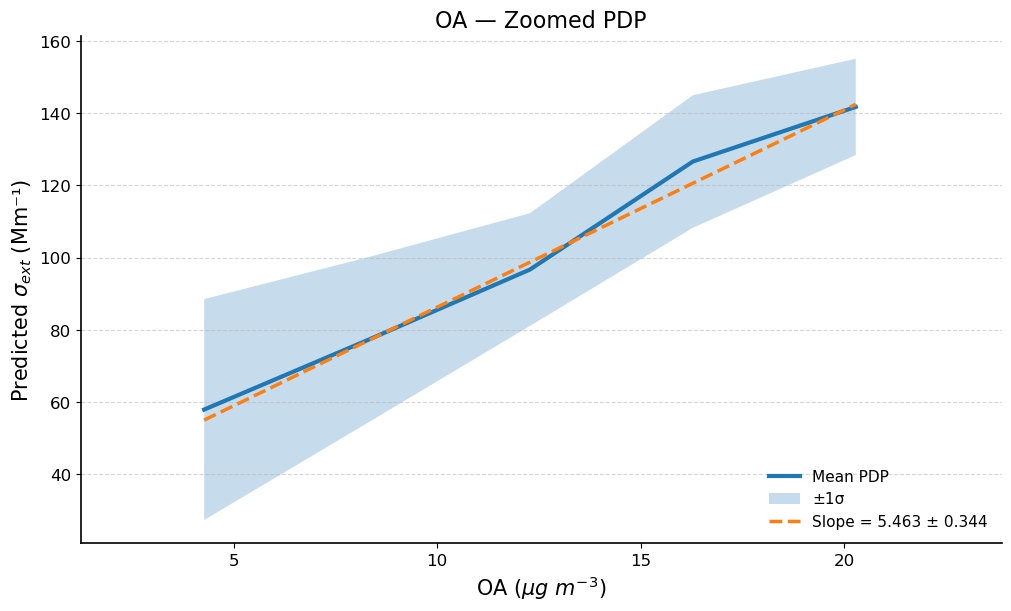

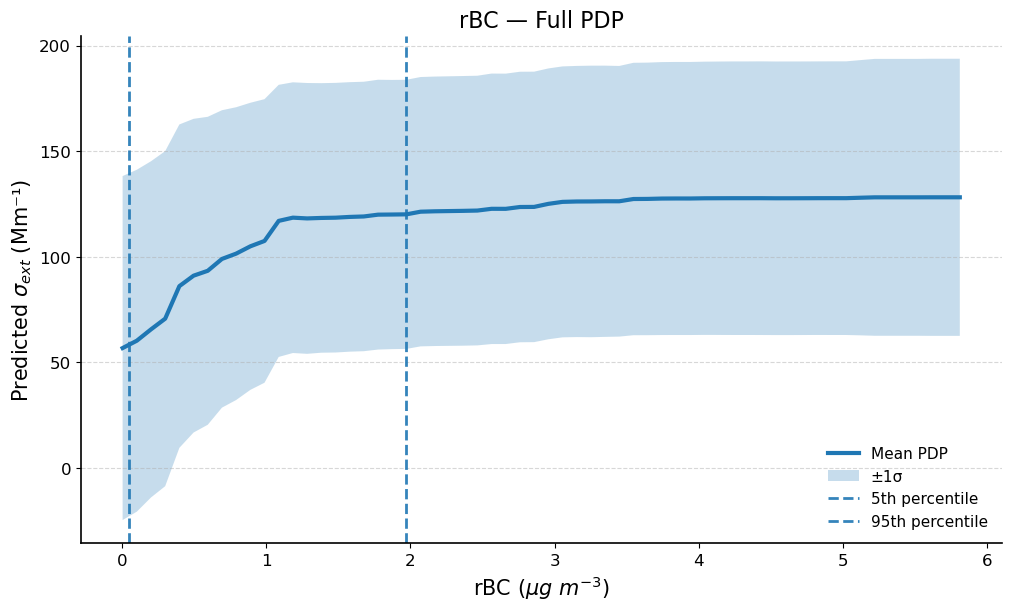

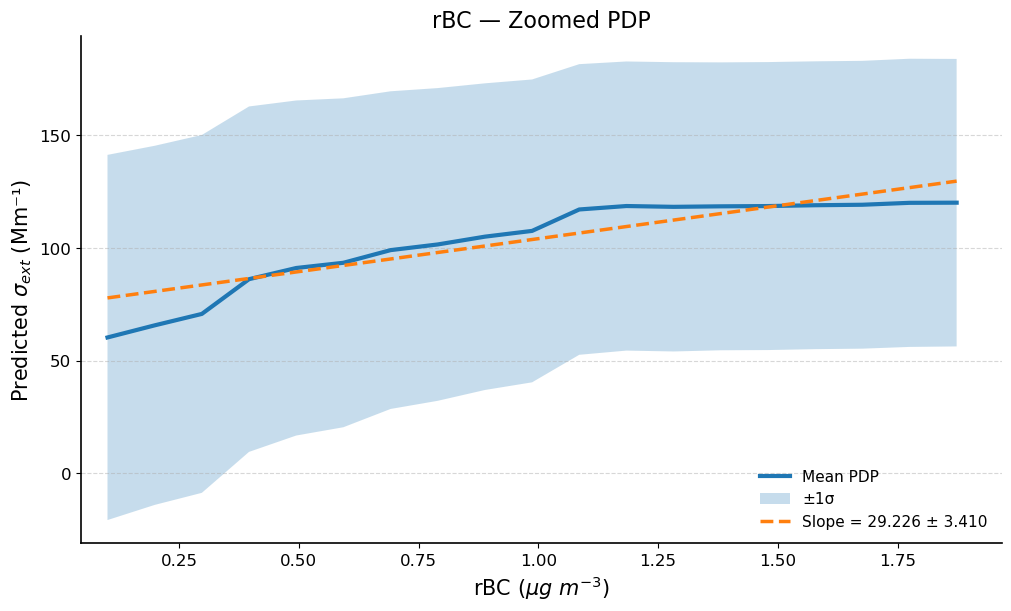

OA: 5.5 ± 0.3
rBC: 29.2 ± 3.4


In [41]:
results = (
    plot_manual_pdp_top2_with_percentile_zoom_uncertainty(
        rf=rf,
        X_train=X_train,
        feat_importances=filtered_feat_importances,
        target_name=r"$\sigma_{ext}$",
        unit_str="(Mm⁻¹)"
    )
)

for feat in results:

    slope = results[feat]["slope"]

    slope_unc = results[feat]["slope_uncertainty"]

    print(
        f"{feat}: "
        f"{slope:.1f} ± {slope_unc:.1f}"
    )

In [17]:
def plot_manual_pdp_top2_combined_figure(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    figsize=(16, 10),
    label_fs=14,
    tick_fs=11,
    legend_fs=15,
    title_fs=14,
    line_width=3,
    panel_label_fs=18
):
    """
    Create ONE figure containing 4 panels:

        a) Top-1 feature — Full PDP
        b) Top-1 feature — Zoomed PDP
        c) Top-2 feature — Full PDP
        d) Top-2 feature — Zoomed PDP

    Layout:
    --------
        [ a ] [ b ]
        [ c ] [ d ]

    Zoomed plots are on the right column.

    Includes:
    ----------
    - 5th/95th percentile lines
    - Weighted linear regression
    - Slope uncertainty propagation
    - Panel labels (a,b,c,d)

    Returns
    -------
    fig, axes, results_dict
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ======================================================
    # PDP computation
    # ======================================================
    def compute_manual_pdp(
        rf,
        X_train,
        feat,
        n_grid=60
    ):

        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None

        grid = np.linspace(
            feat_values.min(),
            feat_values.max(),
            n_grid
        )

        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:

            X_temp = X_train.copy()

            X_temp[feat] = val

            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # ======================================================
    # Top-2 features
    # ======================================================
    all_features = (
        feat_importances
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    if len(all_features) < 2:
        raise ValueError(
            "Need at least 2 features."
        )

    top2_features = all_features[:2]

    y_label = (
        f"Predicted {target_name} {unit_str}"
    ).strip()

    # ======================================================
    # Figure setup
    # ======================================================
    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        constrained_layout=True
    )

    axes = axes.ravel()

    panel_labels = ["a", "b", "c", "d"]

    results_dict = {}

    # ======================================================
    # Loop through features
    # ======================================================
    for i, feat in enumerate(top2_features):

        # ==================================================
        # Compute PDP
        # ==================================================
        result = compute_manual_pdp(
            rf,
            X_train,
            feat,
            n_grid=n_grid
        )

        if result is None:
            continue

        grid, pdp_mean, pdp_std, p05, p95 = result

        # ==================================================
        # Restrict between percentiles
        # ==================================================
        mask = (
            (grid >= p05)
            &
            (grid <= p95)
        )

        grid_zoom = grid[mask]
        pdp_zoom = pdp_mean[mask]
        std_zoom = pdp_std[mask]

        # ==================================================
        # Weighted regression
        # ==================================================
        safe_std = np.where(
            std_zoom == 0,
            1e-12,
            std_zoom
        )

        weights = 1 / (safe_std ** 2)

        fit_coeffs, covariance = np.polyfit(
            grid_zoom,
            pdp_zoom,
            deg=1,
            w=weights,
            cov=True
        )

        slope = fit_coeffs[0]
        intercept = fit_coeffs[1]

        slope_unc = np.sqrt(
            covariance[0, 0]
        )

        fit_line = (
            slope * grid_zoom
            + intercept
        )

        # ==================================================
        # LEFT PANEL — FULL PDP
        # ==================================================
        ax_full = axes[i * 2]

        ax_full.plot(
            grid,
            pdp_mean,
            lw=line_width,
            label="Mean PDP"
        )

        ax_full.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        ax_full.axvline(
            p05,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="5th percentile"
        )

        ax_full.axvline(
            p95,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="95th percentile"
        )

        ax_full.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_full.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_full.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_full.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_full.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_full.grid(False, axis="x")

        ax_full.spines["top"].set_visible(False)
        ax_full.spines["right"].set_visible(False)

        # Panel label
        ax_full.text(
            0.02,
            0.96,
            panel_labels[i * 2],
            transform=ax_full.transAxes,
            fontsize=panel_label_fs,
            fontweight="bold",
            va="top"
        )

        # ==================================================
        # RIGHT PANEL — ZOOMED PDP
        # ==================================================
        ax_zoom = axes[i * 2 + 1]

        ax_zoom.plot(
            grid_zoom,
            pdp_zoom,
            lw=line_width,
            label="Mean PDP"
        )

        ax_zoom.fill_between(
            grid_zoom,
            pdp_zoom - std_zoom,
            pdp_zoom + std_zoom,
            alpha=0.25,
            label="±1σ"
        )

        ax_zoom.plot(
            grid_zoom,
            fit_line,
            linestyle="--",
            linewidth=2.5,
            label=(
                f"Slope = "
                f"{slope:.2f} ± "
                f"{slope_unc:.2f}"
            )
        )

        ax_zoom.set_xlim(
            p05,
            p95
        )

        ax_zoom.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_zoom.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_zoom.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_zoom.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_zoom.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_zoom.grid(False, axis="x")

        ax_zoom.spines["top"].set_visible(False)
        ax_zoom.spines["right"].set_visible(False)

        # Panel label
        ax_zoom.text(
            0.02,
            0.96,
            panel_labels[i * 2 + 1],
            transform=ax_zoom.transAxes,
            fontsize=panel_label_fs,
            fontweight="bold",
            va="top"
        )

        # ==================================================
        # Save results
        # ==================================================
        results_dict[feat] = {

            "slope": slope,
            "slope_uncertainty": slope_unc,
            "intercept": intercept,
            "p05": p05,
            "p95": p95
        }

    plt.show()

    return fig, axes, results_dict

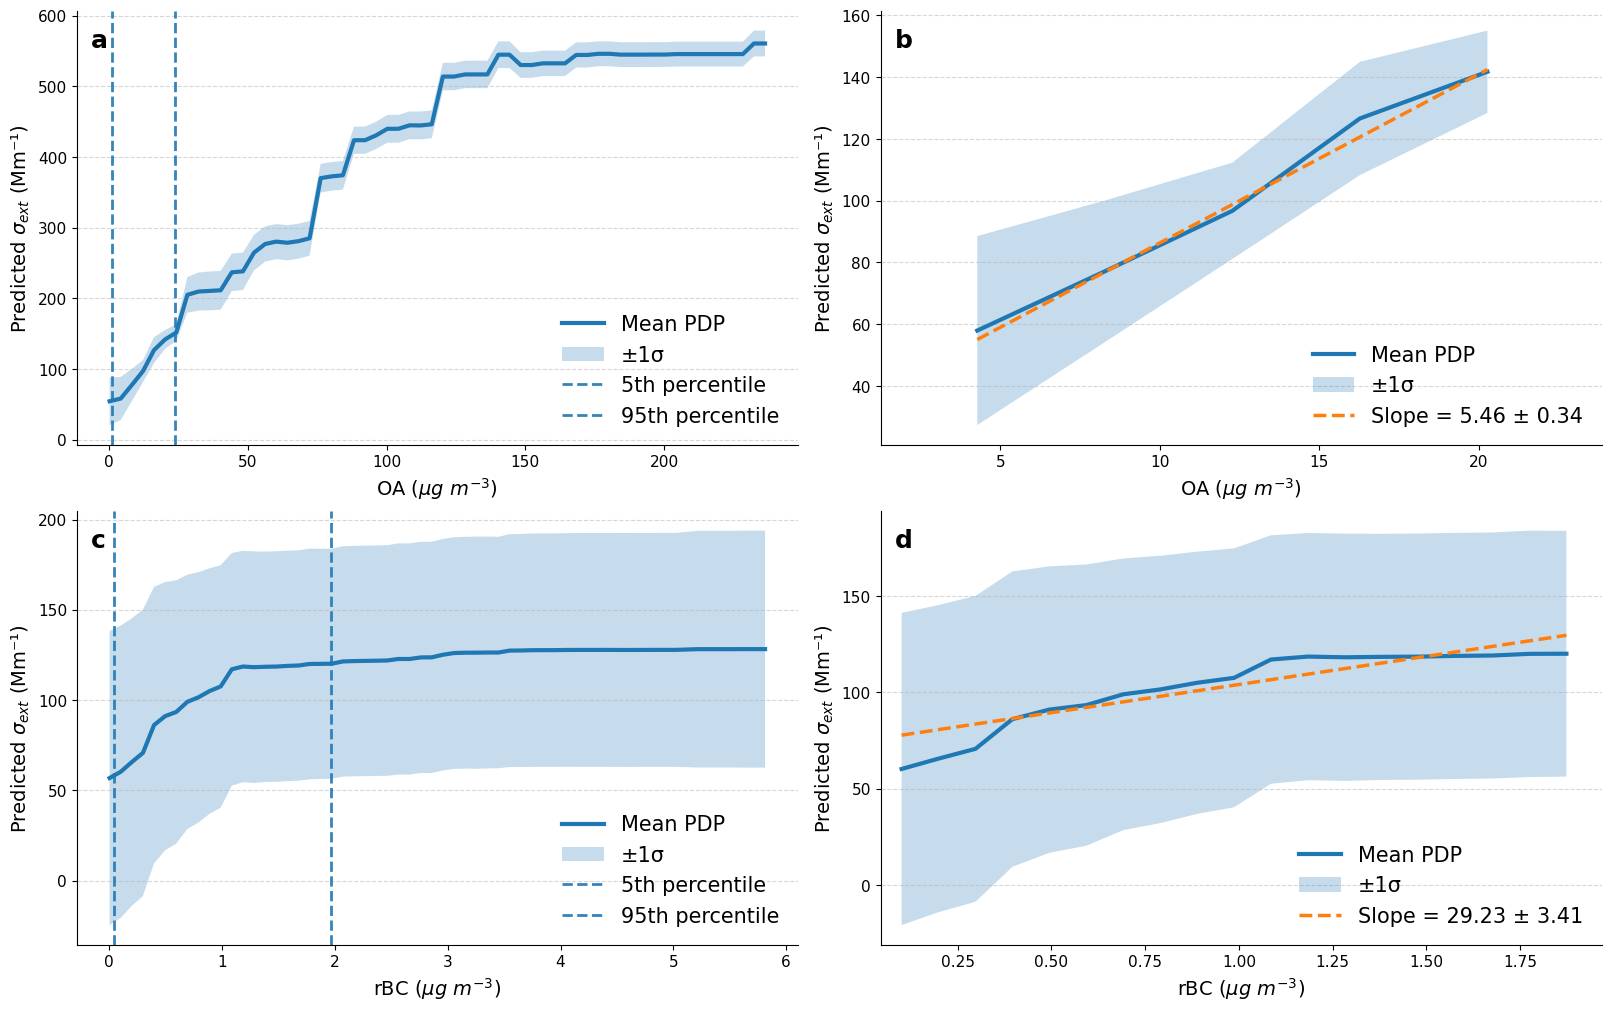

In [18]:
fig, axes, results = (
    plot_manual_pdp_top2_combined_figure(
        rf=rf,
        X_train=X_train,
        feat_importances=filtered_feat_importances,
        target_name=r"$\sigma_{ext}$",
    )
)